In [6]:
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

IN_READY_PATH  = "ships_dataset_cleaned.csv"
LABEL_MAP_PATH = "label_mapping.csv"   

RANDOM_STATE = 42

# Balancing
CAP = 3000

TH_VERY_RARE  = 120
TH_RARE       = 220
TGT_VERY_RARE = 350
TGT_RARE      = 280

# Class-weights
MAX_W = 6.0


#FISHING_OVERSAMPLE_TARGET = 1800  
FISHING_OVERSAMPLE_TARGET = 600  

FISHING_WEIGHT_FACTOR     = 2   

# ==========================================================
# 0) LOAD
# ==========================================================
df = pd.read_csv(IN_READY_PATH)
print(f"[INFO] Loaded {IN_READY_PATH} | shape={df.shape}")

required = {"MMSI", "label"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"[ERROR] Missing required columns: {sorted(missing)}")


# ==========================================================
# 1) FEATURES / TARGET
# ==========================================================
feature_cols = [c for c in df.columns if c not in ["MMSI", "label"]]
X_all = df[feature_cols].to_numpy(dtype=float)
y_all = df["label"].to_numpy(dtype=int)
groups_all = df["MMSI"].to_numpy()

# Prefer robust definition: assumes labels are already contiguous 0..K-1
N_CLASSES = int(y_all.max() + 1) if len(y_all) else 0

print(f"[INFO] Features ({len(feature_cols)}): {feature_cols}")
print(f"[INFO] N_CLASSES from file: {N_CLASSES}")
print("[INFO] Class counts (full):")
print(pd.Series(y_all).value_counts().sort_index())

# ==========================================================
# 2) SPLIT (keep MMSI groups for optional ship-level aggregation)
# ==========================================================
X_train_full, X_test_raw, y_train_full, y_test, groups_train_full, groups_test = train_test_split(
    X_all, y_all, groups_all,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

X_train_raw, X_val_raw, y_train, y_val, groups_train, groups_val = train_test_split(
    X_train_full, y_train_full, groups_train_full,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
)

print("[INFO] Split shapes:",
      f"train={X_train_raw.shape}",
      f"val={X_val_raw.shape}",
      f"test={X_test_raw.shape}")

# ==========================================================
# 3) IMPUTER + SCALER
# ==========================================================
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_raw)
X_val_imp   = imputer.transform(X_val_raw)
X_test_imp  = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_proc = scaler.fit_transform(X_train_imp)
X_val_proc   = scaler.transform(X_val_imp)
X_test_proc  = scaler.transform(X_test_imp)

# ==========================================================
# 4) BALANCING
# 4.1) Soft undersampling of very large classes
# ==========================================================
counts = Counter(y_train)
print("\n[INFO] Train counts (pre-balance):")
for k in sorted(counts):
    print(f"  class {k}: {counts[k]}")

under_strategy = {cls: CAP for cls, n in counts.items() if n > CAP}

if under_strategy:
    rus = RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=under_strategy)
    X_train_bal, y_train_bal = rus.fit_resample(X_train_proc, y_train)
else:
    X_train_bal, y_train_bal = X_train_proc, y_train

print("\n[INFO] Train counts (after undersampling):")
print(pd.Series(y_train_bal).value_counts().sort_index())


FISHING_ID = 1
# ==========================================================
# LOAD CLASS NAMES FROM MAPPING (recommended)
# ==========================================================
class_names = None
try:
    map_df = pd.read_csv(LABEL_MAP_PATH)
    if {"new_id", "class_name"}.issubset(map_df.columns):
        class_names = map_df.sort_values("new_id")["class_name"].tolist()
        if len(class_names) != N_CLASSES:
            print("[WARN] label_mapping size != N_CLASSES. Using generic names.")
            class_names = [f"Class {i}" for i in range(N_CLASSES)]
    else:
        print("[WARN] label_mapping.csv missing expected columns. Using generic names.")
        class_names = [f"Class {i}" for i in range(N_CLASSES)]
except Exception:
    print("[WARN] label_mapping.csv not found. Using generic names.")
    class_names = [f"Class {i}" for i in range(N_CLASSES)]

# ==========================================================
# 4.2) Micro-oversampling for rare classes 
# ==========================================================
counts_under = Counter(y_train_bal)
over_strategy = {}

for cls, n in counts_under.items():
    tgt = None
    if n < TH_VERY_RARE:
        tgt = TGT_VERY_RARE
    elif n < TH_RARE:
        tgt = TGT_RARE
    if tgt is not None and tgt > n:
        over_strategy[cls] = tgt

# Optional targeted Fishing oversampling
if FISHING_OVERSAMPLE_TARGET is not None and FISHING_ID is not None:
    if FISHING_ID in counts_under and counts_under[FISHING_ID] < FISHING_OVERSAMPLE_TARGET:
        over_strategy[FISHING_ID] = max(over_strategy.get(FISHING_ID, 0), FISHING_OVERSAMPLE_TARGET)
        print(f"[INFO] Targeted Fishing oversampling -> {over_strategy[FISHING_ID]}")

if over_strategy:
    ros = RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=over_strategy)
    X_train_bal, y_train_bal = ros.fit_resample(X_train_bal, y_train_bal)

print("\n[INFO] Train counts (after oversampling):")
print(pd.Series(y_train_bal).value_counts().sort_index())

# ==========================================================
# 4.3) CLASS WEIGHTS (based on pre-over distribution)
# ==========================================================
median_count = np.median(list(counts_under.values())) if counts_under else 1.0
class_weight = {cls: float(median_count / cnt) for cls, cnt in counts_under.items()}
class_weight = {cls: min(MAX_W, w) for cls, w in class_weight.items()}

# ----------------------------------------------------------
# Targeted Fishing WEIGHT (by ID)
# ----------------------------------------------------------
if FISHING_WEIGHT_FACTOR is not None and FISHING_WEIGHT_FACTOR != 1.0:
    old = class_weight.get(FISHING_ID, 1.0)
    class_weight[FISHING_ID] = min(MAX_W, old * FISHING_WEIGHT_FACTOR)
    print(f"[INFO] Targeted Fishing weight (id={FISHING_ID}) -> {old:.3f} → {class_weight[FISHING_ID]:.3f}")

print("\n[INFO] class_weight:")
for k in sorted(class_weight):
    print(f"  class {k}: {class_weight[k]:.3f}")

# ==========================================================
# 5) MINIMAL SAFETY CHECK
# ==========================================================
assert int(y_test.max()) < N_CLASSES, (
    f"[ERROR] y_test contains out-of-range labels: max={int(y_test.max())}, N_CLASSES={N_CLASSES}"
)

print("\n[OK] Data pipeline ready for training.")


[INFO] Loaded ships_dataset_cleaned.csv | shape=(11046, 13)
[INFO] Features (11): ['Length', 'Width', 'Draft', 'L_over_W', 'W_over_L', 'area_proxy', 'L_over_D', 'W_over_D', 'log_area_proxy', 'sog_mean', 'log_sog_mean']
[INFO] N_CLASSES from file: 17
[INFO] Class counts (full):
0     2000
1      571
2      723
3     2000
4     1163
5      279
6      110
7      337
8     2000
9      170
10     831
11     277
12      84
13     278
14      77
15      62
16      84
Name: count, dtype: int64
[INFO] Split shapes: train=(7068, 11) val=(1768, 11) test=(2210, 11)

[INFO] Train counts (pre-balance):
  class 0: 1280
  class 1: 365
  class 2: 462
  class 3: 1280
  class 4: 744
  class 5: 178
  class 6: 70
  class 7: 215
  class 8: 1280
  class 9: 109
  class 10: 532
  class 11: 177
  class 12: 54
  class 13: 178
  class 14: 50
  class 15: 40
  class 16: 54

[INFO] Train counts (after undersampling):
0     1280
1      365
2      462
3     1280
4      744
5      178
6       70
7      215
8     1280
9

Model: "NN_cfg25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │      3,072 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_2      │ (None, 256)       │          0 │ dropout_1[0][0],  │
│ (Add)               │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ residual_add_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_4                │ (None, 128)       │        512 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ bn_4[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_4      │ (None, 128)       │          0 │ dropout_3[0][0],  │
│ (Add)               │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 17)        │      2,193 │ residual_add_4[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,537 (482.57 KB)

 Trainable params: 122,001 (476.57 KB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/300
10/10 - 10s - 993ms/step - accuracy: 0.3008 - loss: 2.7147 - val_accuracy: 0.5373 - val_loss: 1.8332 - learning_rate: 0.0010
Epoch 2/300
10/10 - 1s - 56ms/step - accuracy: 0.5258 - loss: 1.5232 - val_accuracy: 0.5741 - val_loss: 1.6315 - learning_rate: 0.0010
Epoch 3/300
10/10 - 0s - 48ms/step - accuracy: 0.5881 - loss: 1.2725 - val_accuracy: 0.6369 - val_loss: 1.4954 - learning_rate: 0.0010
Epoch 4/300
10/10 - 1s - 96ms/step - accuracy: 0.6203 - loss: 1.1441 - val_accuracy: 0.6686 - val_loss: 1.4509 - learning_rate: 0.0010
Epoch 5/300
10/10 - 1s - 96ms/step - accuracy: 0.6432 - loss: 1.0418 - val_accuracy: 0.6787 - val_loss: 1.4131 - learning_rate: 0.0010
Epoch 6/300
10/10 - 1s - 92ms/step - accuracy: 0.6582 - loss: 1.0026 - val_accuracy: 0.6821 - val_loss: 1.3584 - learning_rate: 0.0010
Epoch 7/300
10/10 - 0s - 48ms/step - accuracy: 0.6740 - loss: 0.9251 - val_accuracy: 0.7115 - val_loss: 1.3148 - learning_rate: 0.0010
Epoch 8/300
10/10 - 0s - 35ms/step - accuracy: 0.6888

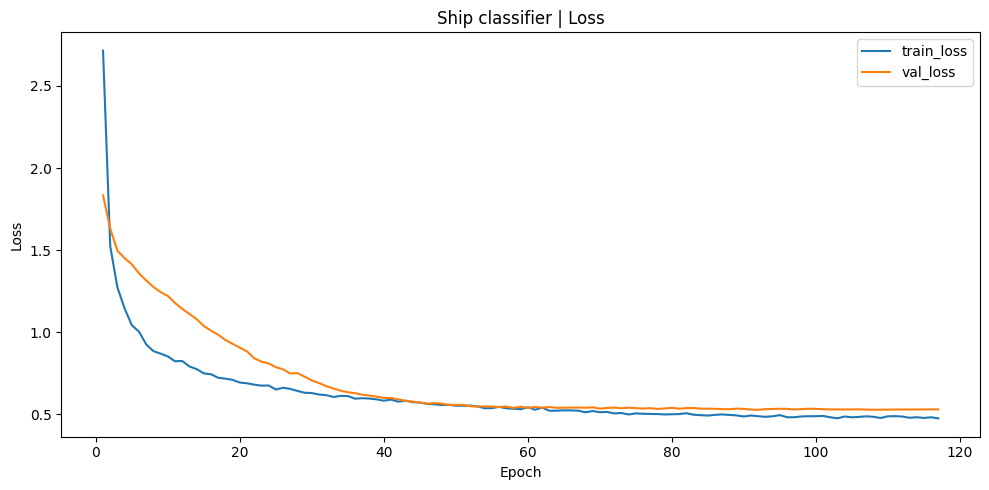

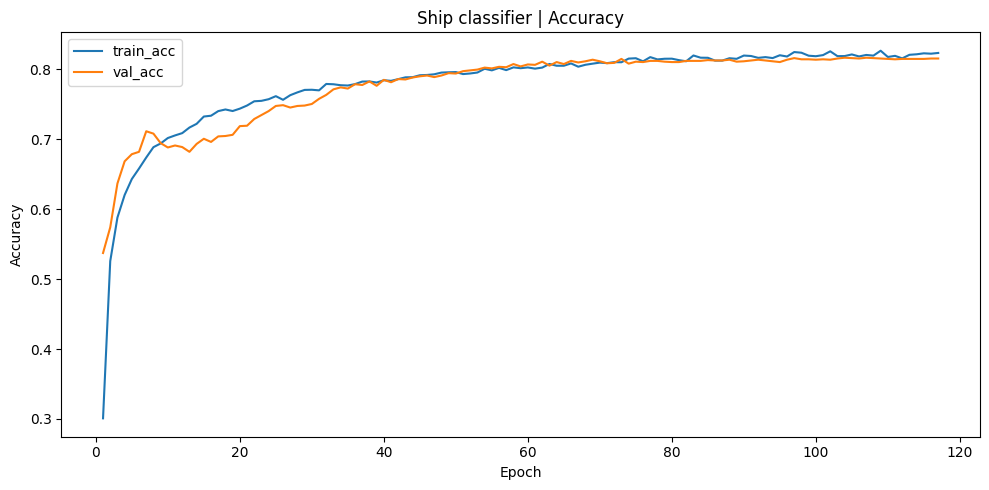

[TEST] Loss=0.5051 | Accuracy=0.8149


In [7]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ==========================================================
# CFG_25 HYPERPARAMETERS
# ==========================================================
Model_NN = {
    "hidden_units": (256, 256, 128, 128),
    "dropout_rates": (0.35, 0.35, 0.30, 0.30),
    "l2_reg": 1e-5,
    "lr": 1e-3,
    "smoothing": 0.00,
    "batch_size": 1024,
    "max_epochs": 300,
    "seed": 42,
}

np.random.seed(Model_NN["seed"])
tf.random.set_seed(Model_NN["seed"])

input_dim = X_train_bal.shape[1]



# building model
def build_model(input_dim: int, n_classes: int, cfg: dict) -> keras.Model:
    hu = cfg["hidden_units"]
    dr = cfg["dropout_rates"]

    inputs = keras.Input(shape=(input_dim,), name="features")
    x = inputs

    for i, (units, drop_rate) in enumerate(zip(hu, dr), start=1):
        dense = layers.Dense(
            units,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(cfg["l2_reg"]),
            name=f"dense_{i}",
        )(x)

        x_new = layers.BatchNormalization(name=f"bn_{i}")(dense)
        x_new = layers.Dropout(drop_rate, name=f"dropout_{i}")(x_new)

        # Residual if shapes match
        if x.shape[-1] == x_new.shape[-1]:
            x = layers.Add(name=f"residual_add_{i}")([x, x_new])
        else:
            x = x_new

    outputs = layers.Dense(n_classes, activation="softmax", name="predictions")(x)
    model = keras.Model(inputs, outputs, name="NN_cfg25")

    # Keep your safe custom loss (sparse label -> one-hot internally)
    base = keras.losses.CategoricalCrossentropy(label_smoothing=cfg["smoothing"])

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=n_classes)
        return base(y_true_oh, y_pred)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg["lr"]),
        loss=loss_fn,
        metrics=["accuracy"],
    )
    return model

model_cfg25 = build_model(input_dim, N_CLASSES, Model_NN)
model_cfg25.summary()

# ==========================================================
# CALLBACKS
# ==========================================================
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-5,
        verbose=1,
    ),
]

# ==========================================================
# TRAIN
# ==========================================================
history_cfg25 = model_cfg25.fit(
    X_train_bal, y_train_bal,
    validation_data=(X_val_proc, y_val),
    epochs=Model_NN["max_epochs"],
    batch_size=Model_NN["batch_size"],
    callbacks=callbacks,
    verbose=2,
    class_weight=class_weight
)

# ==========================================================
# SAVE
# ==========================================================
model_cfg25.save("model_cfg25_retrained.keras")
print("[OK] Model saved -> model_cfg25_retrained.keras")

# ==========================================================
# PLOT CURVES
# ==========================================================
def plot_history(hist):
    h = hist.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, h["loss"], label="train_loss")
    plt.plot(epochs, h["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Ship classifier | Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, h["accuracy"], label="train_acc")
    plt.plot(epochs, h["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Ship classifier | Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_cfg25)

# ==========================================================
# TEST EVALUATION
# ==========================================================
test_loss, test_acc = model_cfg25.evaluate(X_test_proc, y_test, verbose=0)
print(f"[TEST] Loss={test_loss:.4f} | Accuracy={test_acc:.4f}")


[TEST] Loss=0.5051 | Accuracy=0.8149

[TEST] Classification report:
                           precision    recall  f1-score   support

                    Cargo     0.7136    0.7225    0.7180       400
                  Fishing     0.5472    0.5088    0.5273       114
                Passenger     0.7903    0.6759    0.7286       145
                   Tanker     0.7605    0.7700    0.7652       400
                      Tug     0.8534    0.8498    0.8516       233
Dredging / Underwater ops     0.8462    0.9821    0.9091        56
               Diving ops     0.6071    0.7727    0.6800        22
             Military ops     0.9062    0.8529    0.8788        68
       Sailing & Pleasure     0.9713    0.9300    0.9502       400
             Pilot Vessel     0.8529    0.8529    0.8529        34
          Search & Rescue     0.9593    0.9940    0.9763       166
              Port Tender     0.8929    0.9091    0.9009        55
           Anti-pollution     0.7000    0.8235    0.7568    

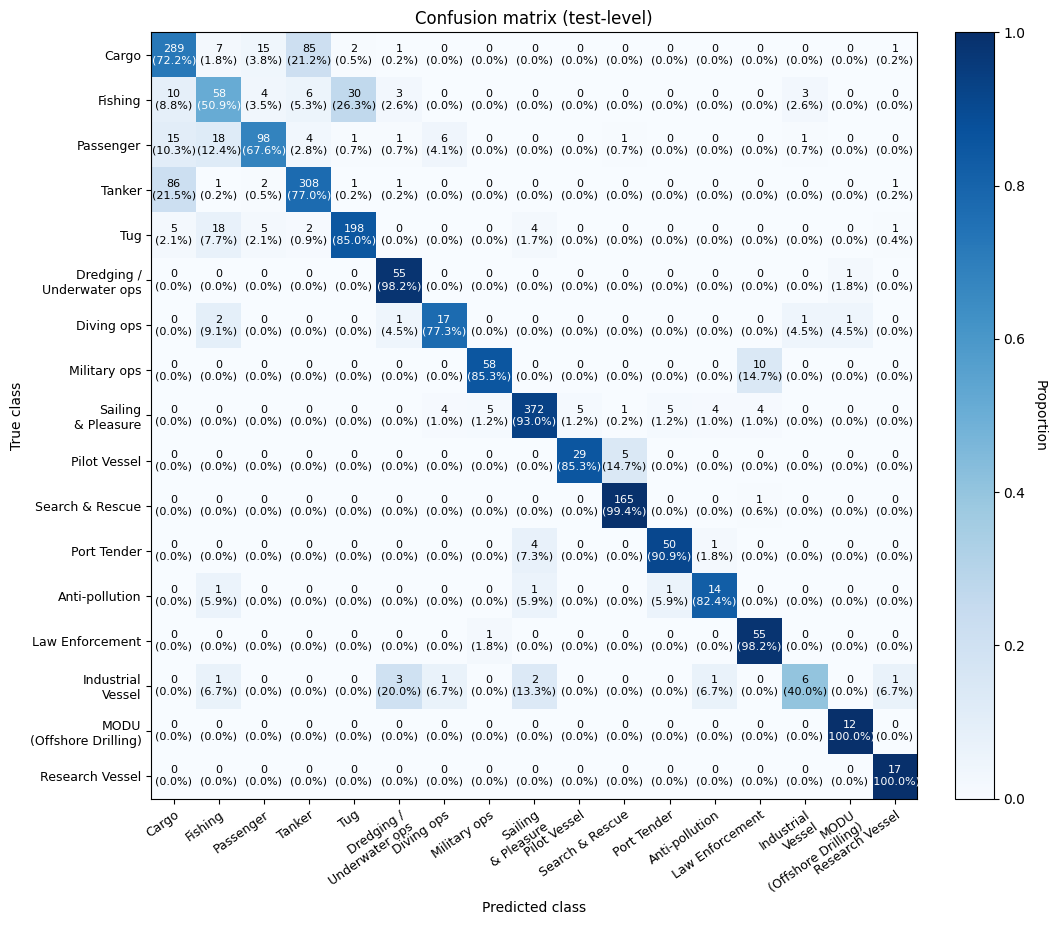

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

model = model_cfg25

N_CLASSES = int(model.output_shape[-1])

# ==========================================================
# CLASS NAMES FALLBACK
# ==========================================================
if "class_names" not in globals() or class_names is None or len(class_names) != N_CLASSES:
    class_names = [f"Class {i}" for i in range(N_CLASSES)]
    print("[WARN] class_names not available or not aligned with the model. Using generic names.")

# ==========================================================
# WRAP LABELS FOR PLOTS
# ==========================================================
def wrap_label(s, max_len=16):
    s = str(s)
    if len(s) <= max_len:
        return s
    parts = s.split(" ")
    if len(parts) == 1:
        return s
    mid = len(parts) // 2
    return " ".join(parts[:mid]) + "\n" + " ".join(parts[mid:])

class_names_wrapped = [wrap_label(n) for n in class_names]

# ==========================================================
# PRETTY CONFUSION MATRIX (row-normalized)
# ==========================================================
def plot_confusion_matrix_pretty(cm, class_names, title="Confusion matrix"):
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm.astype(float),
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0
    )

    n = len(class_names)
    fig_w = max(10, 0.65 * n)
    fig_h = max(8,  0.55 * n)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Proportion", rotation=270, labelpad=15)

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(class_names, fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", rotation_mode="anchor")

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)

    thresh = cm_norm.max() / 2.0 if cm_norm.size else 0.5

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            perc = (cm_norm[i, j] * 100) if row_sums[i] != 0 else 0.0
            text_color = "white" if cm_norm[i, j] > thresh else "black"
            ax.text(
                j, i,
                f"{count}\n({perc:.1f}%)",
                ha="center", va="center",
                color=text_color,
                fontsize=8
            )

    ax.grid(False)
    fig.tight_layout()
    plt.show()

# ==========================================================
# TEST-LEVEL EVALUATION
# ==========================================================
y_test_arr = np.asarray(y_test).astype(int)

test_loss, test_acc = model.evaluate(X_test_proc, y_test_arr, verbose=0)
print(f"[TEST] Loss={test_loss:.4f} | Accuracy={test_acc:.4f}")

y_proba_test = model.predict(X_test_proc, batch_size=4096, verbose=0)
y_pred_test = y_proba_test.argmax(axis=1)

print("\n[TEST] Classification report:")
print(classification_report(
    y_test_arr, y_pred_test,
    labels=list(range(N_CLASSES)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm_test = confusion_matrix(y_test_arr, y_pred_test, labels=list(range(N_CLASSES)))
print("\n[TEST] Confusion matrix (rows=true, cols=pred):")
print(cm_test)

plot_confusion_matrix_pretty(cm_test, class_names_wrapped, title="Confusion matrix (test-level)")



In [9]:
from tensorflow.keras.utils import plot_model

plot_model(
    model_cfg25,
    to_file="NN_cfg25_arch.png",
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",   # top-to-bottom (perfetto per slide)
    dpi=200
)

print("Saved: NN_cfg25_arch.png")


Saved: NN_cfg25_arch.png


[TEST] Loss=0.5051 | Accuracy=0.8149

[TEST] Classification report:
                           precision    recall  f1-score   support

                    Cargo     0.7136    0.7225    0.7180       400
                  Fishing     0.5472    0.5088    0.5273       114
                Passenger     0.7903    0.6759    0.7286       145
                   Tanker     0.7605    0.7700    0.7652       400
                      Tug     0.8534    0.8498    0.8516       233
Dredging / Underwater ops     0.8462    0.9821    0.9091        56
               Diving ops     0.6071    0.7727    0.6800        22
             Military ops     0.9062    0.8529    0.8788        68
       Sailing & Pleasure     0.9713    0.9300    0.9502       400
             Pilot Vessel     0.8529    0.8529    0.8529        34
          Search & Rescue     0.9593    0.9940    0.9763       166
              Port Tender     0.8929    0.9091    0.9009        55
           Anti-pollution     0.7000    0.8235    0.7568    

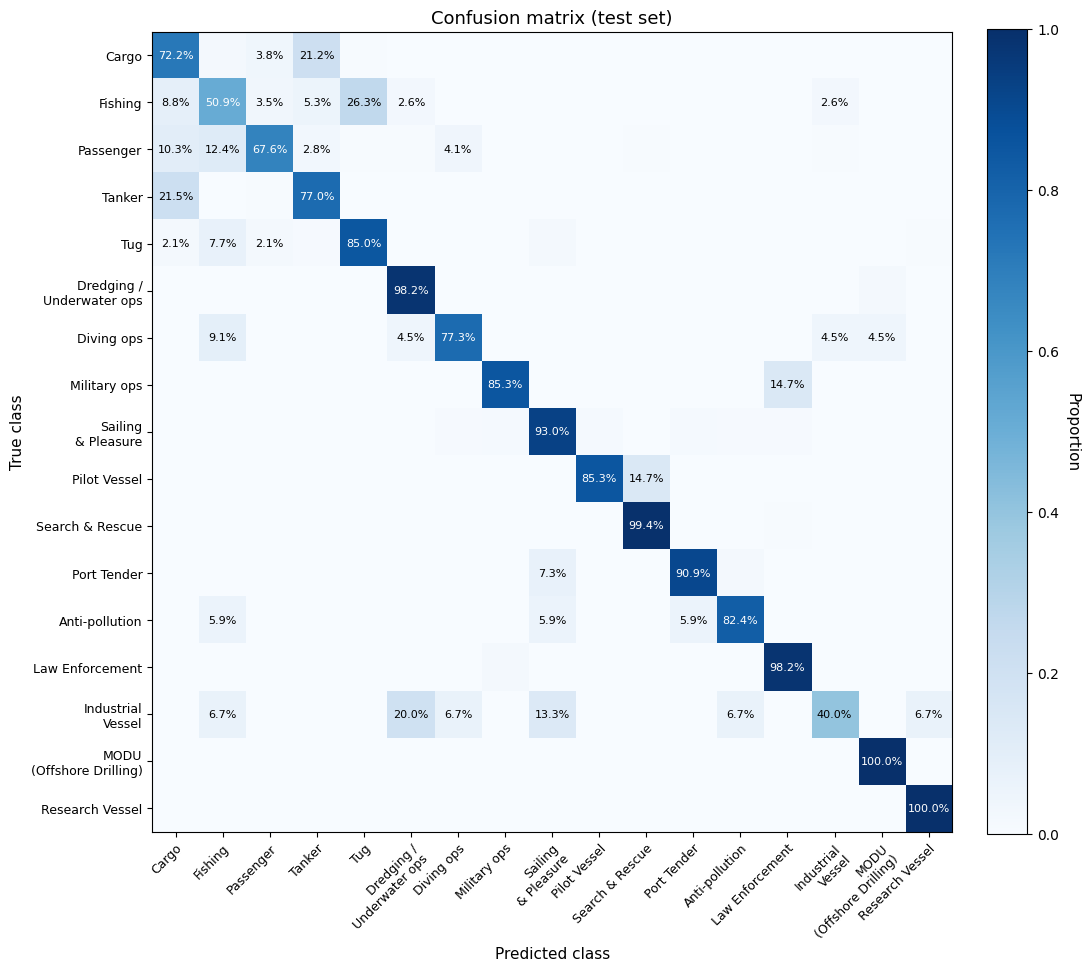

In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

model = model_cfg25

N_CLASSES = int(model.output_shape[-1])

# ==========================================================
# CLASS NAMES FALLBACK
# ==========================================================
if "class_names" not in globals() or class_names is None or len(class_names) != N_CLASSES:
    class_names = [f"Class {i}" for i in range(N_CLASSES)]
    print("[WARN] class_names not available or not aligned with the model. Using generic names.")

# ==========================================================
# WRAP LABELS FOR PLOTS (va benissimo tenerlo)
# ==========================================================
def wrap_label(s, max_len=16):
    s = str(s)
    if len(s) <= max_len:
        return s
    parts = s.split(" ")
    if len(parts) == 1:
        return s
    mid = len(parts) // 2
    return " ".join(parts[:mid]) + "\n" + " ".join(parts[mid:])

class_names_wrapped = [wrap_label(n) for n in class_names]

# ==========================================================
# PRETTY CONFUSION MATRIX (row-normalized, versione da slide)
# ==========================================================
def plot_confusion_matrix_pretty(
    cm,
    class_names,
    title="Confusion matrix",
    show_threshold=0.02,
    savepath=None
):
    """
    cm: confusion matrix (rows = true, cols = pred)
    class_names: list of labels (wrapped)
    show_threshold: mostri il testo solo se la proporzione > soglia (es. 0.02 = 2%)
    savepath: se non None, salva la figura in PNG ad alta risoluzione
    """
    # normalizzazione per riga
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm.astype(float),
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0
    )

    n = len(class_names)

    # Figura grande, pensata per presentazioni
    fig, ax = plt.subplots(figsize=(11, 11))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0.0, vmax=1.0)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Proportion", rotation=270, labelpad=15, fontsize=11)

    # Tick e label
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(class_names, fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    ax.set_xlabel("Predicted class", fontsize=11)
    ax.set_ylabel("True class", fontsize=11)
    ax.set_title(title, fontsize=13)

    # Testo solo nelle celle "importanti"
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm_norm[i, j]
            if val >= show_threshold:
                perc = val * 100.0
                text_color = "white" if val > 0.5 else "black"
                ax.text(
                    j, i,
                    f"{perc:.1f}%",   # solo percentuale
                    ha="center", va="center",
                    color=text_color,
                    fontsize=8
                )

    ax.grid(False)
    fig.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"[INFO] Confusion matrix saved to {savepath} (dpi=300)")

    plt.show()

# ==========================================================
# TEST-LEVEL EVALUATION
# ==========================================================
y_test_arr = np.asarray(y_test).astype(int)

test_loss, test_acc = model.evaluate(X_test_proc, y_test_arr, verbose=0)
print(f"[TEST] Loss={test_loss:.4f} | Accuracy={test_acc:.4f}")

# Predizioni
y_proba_test = model.predict(X_test_proc, batch_size=4096, verbose=0)
y_pred_test = y_proba_test.argmax(axis=1)

print("\n[TEST] Classification report:")
print(
    classification_report(
        y_test_arr,
        y_pred_test,
        labels=list(range(N_CLASSES)),
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

# Confusion matrix
cm_test = confusion_matrix(y_test_arr, y_pred_test, labels=list(range(N_CLASSES)))
print("\n[TEST] Confusion matrix (rows=true, cols=pred):")
print(cm_test)

# Plot "bello" per la presentazione
plot_confusion_matrix_pretty(
    cm_test,
    class_names_wrapped,
    title="Confusion matrix (test set)",
    show_threshold=0.02,                  # mostra testo solo se > 2%
    savepath="confusion_matrix_test.png"  # file PNG ad alta risoluzione
)
